In [1]:
import os
import matplotlib as mpl
import numpy as np
import pandas as pd
import scanpy as sc
import celltypist
from celltypist import models
import scvi
import gc

sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=80, facecolor='white', color_map='viridis')
sc.logging.print_header()

/opt/conda/envs/autoimmune/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scanpy==1.9.8 anndata==0.10.5.post1 umap==0.5.5 numpy==1.26.4 scipy==1.12.0 pandas==1.5.3 scikit-learn==1.4.1.post1 statsmodels==0.14.1 igraph==0.11.4 pynndescent==0.5.11


In [2]:
import scarches as sca
#from scarches.dataset.trvae.data_handling import remove_sparsity

In order to use the mouse gastrulation seqFISH datsets, please install squidpy (see https://github.com/scverse/squidpy).
In order to use sagenet models, please install pytorch geometric (see https://pytorch-geometric.readthedocs.io) and 
 captum (see https://github.com/pytorch/captum).
mvTCR is not installed. To use mvTCR models, please install it first using "pip install mvtcr"
multigrate is not installed. To use multigrate models, please install it first using "pip install multigrate".


In [3]:
import torch

In [4]:
import gdown
#import scarches as sca
#from scarches.dataset.trvae.data_handling import remove_sparsity

In [5]:
torch.set_printoptions(precision=3, sci_mode=False, edgeitems=7)

In [6]:
print(sc.__version__)

1.9.8


In [7]:
print(scvi.__version__)

1.1.1


In [8]:
#dir_save="/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/Immune_compartment_PBMC/Subset/"
#path='/nfs/team205/bh14/Datasets/Remapped/raw_adata/QC_concatenated/'

In [9]:
#adata = sc.read_h5ad('Immune_compartment_QC_filtered_2.h5ad')

In [10]:
#del adata

In [11]:
def load_sub_adata(adata, obs_file):
    obs = pd.read_csv(obs_file, index_col=0)
    if "scvi_clusters" in obs.columns:
        obs.drop(columns="scvi_clusters", inplace=True)
    temp = adata[obs.index].copy()
    temp.obs = obs
    return temp

In [12]:
def load_model(adata, save_path, obs_file_path):
    
    adata_hvg = load_sub_adata(adata=adata, obs_file=obs_file_path)
    
    print("running hvg")

    sc.pp.highly_variable_genes(
        adata_hvg, 
        flavor="seurat_v3", 
        n_top_genes=2000, 
        layer="counts", 
        batch_key="batch",
        subset=True
    )
                               
    print("loading model .....")
    
    vae = scvi.model.SCVI.load(save_path, adata=adata_hvg, use_gpu=True)
    vae.get_latent_representation()
    
    return vae

In [13]:
adata_query = sc.read_h5ad("Braga_asthma_lung_celltypist.h5ad")


In [14]:
sc.set_figure_params(figsize=(9,9))

In [15]:
adata_query

AnnData object with n_obs × n_vars = 96803 × 27468
    obs: 'dataset_id', 'donor_id', 'tissue', 'cell_source', 'disease', 'disease_status', 'age', 'sex', 'developmental_stage', 'sample_id', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'main_predicted_cell_groups'
    var: 'n_counts', 'mt', 'rb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'leiden', 'log1p', 'neighbors'
    obsm: 'X_pca'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [16]:
sc.tl.pca(adata_query, svd_solver='arpack')

computing PCA
    with n_comps=50
    finished (0:01:27)


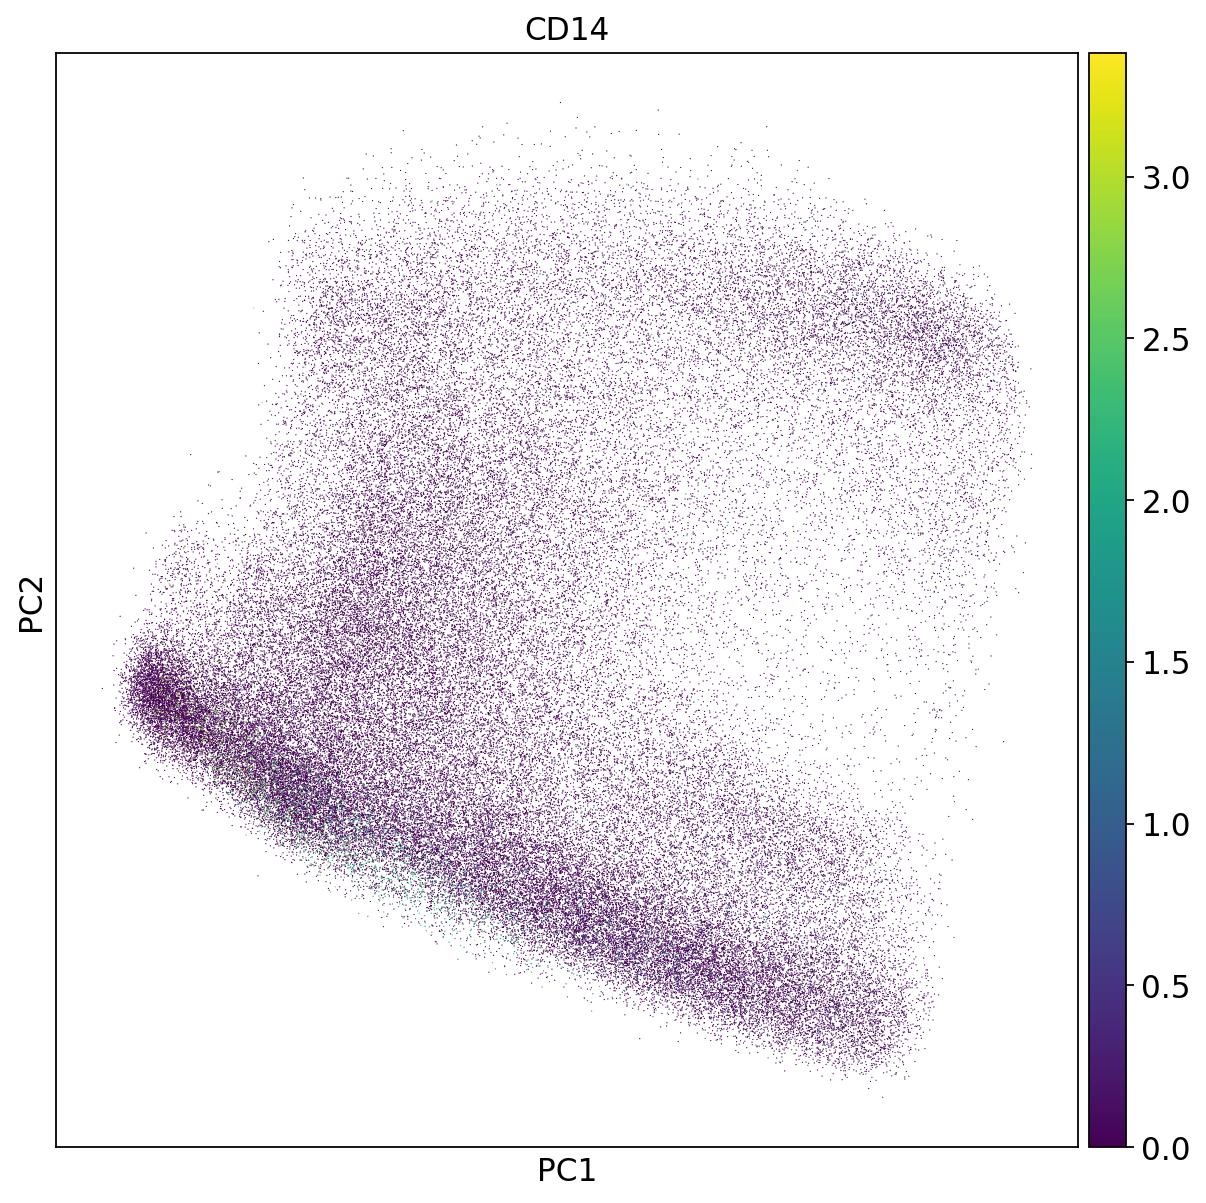

In [17]:
sc.pl.pca(adata_query, color='CD14')

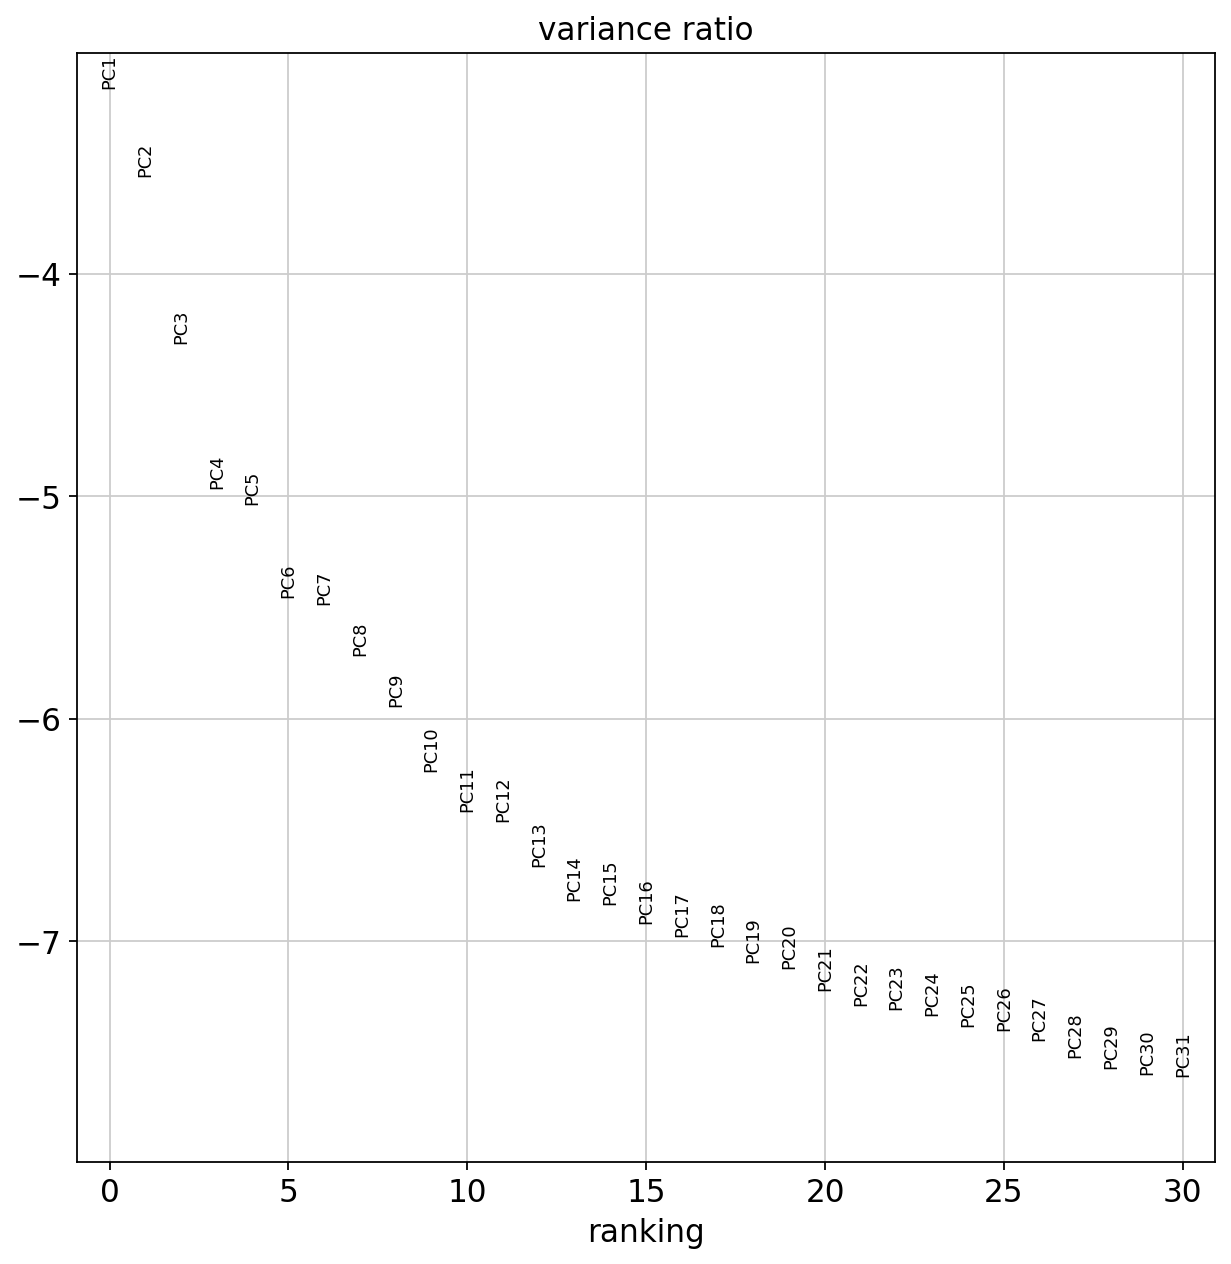

In [18]:
sc.pl.pca_variance_ratio(adata_query, log=True)

In [19]:
sc.pp.neighbors(adata_query, n_neighbors=30, n_pcs=15)

computing neighbors
    using 'X_pca' with n_pcs = 15
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:35)


In [21]:
sc.tl.leiden(adata_query, resolution=0.6)

running Leiden clustering
    finished: found 24 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:37)


In [22]:
sc.tl.paga(adata_query)
sc.pl.paga(adata_query, plot=False)  # remove `plot=False` if you want to see the coarse-grained graph
sc.tl.umap(adata_query, init_pos='paga')

running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:05)
--> added 'pos', the PAGA positions (adata.uns['paga'])
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:01:28)


In [ ]:
sc.set_figure_params(figsize=(12,12))
sc.pl.umap(
    adata_query,
    color=["majority_voting", "main_predicted_cell_groups"],
    frameon=False,
    size=6,
    ncols=2,
    legend_fontoutline=4,
    legend_fontsize=10,
    legend_loc="on data"
)

In [24]:
adata_query.write_h5ad('Braga_asthma_lung_celltypist.h5ad')

In [25]:
adata_query = sc.read_h5ad("Braga_asthma_lung_celltypist.h5ad")

In [26]:
adata_query.obs.main_predicted_cell_groups.unique()[:10]

['Multiciliated (non-nasal)', 'Basal resting', 'Suprabasal', 'EC venous systemic', 'Goblet (nasal)', 'Classical monocytes', 'Club (non-nasal)', 'Mast cells', 'CD4 T cells', 'DC2']
Categories (26, object): ['Alveolar macrophages', 'B cells', 'Basal resting', 'CD4 T cells', ..., 'SMG mucous', 'SMG serous (bronchial)', 'Smooth muscle', 'Suprabasal']

In [27]:
adata_query.obs.main_predicted_cell_groups.unique()[10:20]

['SMG mucous', 'CD8 T cells', 'Peribronchial fibroblasts', 'Non-classical monocytes', 'SMG duct', 'SMG serous (bronchial)', 'Alveolar macrophages', 'EC arterial', 'Ionocyte', 'NK cells']
Categories (26, object): ['Alveolar macrophages', 'B cells', 'Basal resting', 'CD4 T cells', ..., 'SMG mucous', 'SMG serous (bronchial)', 'Smooth muscle', 'Suprabasal']

In [28]:
adata_query.obs.main_predicted_cell_groups.unique()[20:]

['Smooth muscle', 'B cells', 'Plasmacytoid DCs', 'Plasma cells', 'Lymphatic EC mature', 'Goblet (bronchial)']
Categories (26, object): ['Alveolar macrophages', 'B cells', 'Basal resting', 'CD4 T cells', ..., 'SMG mucous', 'SMG serous (bronchial)', 'Smooth muscle', 'Suprabasal']

In [29]:
adata_query.obs.main_predicted_cell_groups.value_counts()

Multiciliated (non-nasal)    33032
Suprabasal                   22014
Basal resting                12363
CD8 T cells                   7264
CD4 T cells                   4595
Club (non-nasal)              4052
EC venous systemic            3208
DC2                           1700
Classical monocytes           1671
Peribronchial fibroblasts     1182
B cells                        802
Mast cells                     793
Plasma cells                   558
Goblet (bronchial)             508
Goblet (nasal)                 465
Smooth muscle                  415
NK cells                       371
SMG duct                       313
Ionocyte                       279
SMG serous (bronchial)         270
Non-classical monocytes        240
EC arterial                    224
SMG mucous                     184
Alveolar macrophages           133
Plasmacytoid DCs               126
Lymphatic EC mature             41
Name: main_predicted_cell_groups, dtype: int64

In [30]:
adata_query = adata_query[adata_query.obs.main_predicted_cell_groups.isin(['Classical monocytes', 'Mast cells', 'CD4 T cells', 
                                                           'DC2', 'CD8 T cells', 'Non-classical monocytes', 'NK cells', 
                                                           'B cells', 'Alveolar macrophages', 'Plasmacytoid DCs', 'Plasma cells'])].copy()

In [31]:
adata_query

AnnData object with n_obs × n_vars = 18253 × 27468
    obs: 'dataset_id', 'donor_id', 'tissue', 'cell_source', 'disease', 'disease_status', 'age', 'sex', 'developmental_stage', 'sample_id', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'main_predicted_cell_groups', 'leiden'
    var: 'n_counts', 'mt', 'rb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'leiden', 'leiden_sizes', 'log1p', 'main_predicted_cell_groups_colors', 'majority_voting_colors', 'neighbors', 'paga', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [ ]:
sc.pl.umap(
    adata_query,
    color=["main_predicted_cell_groups", "majority_voting"],
    frameon=False,
    size=6,
    ncols=2,
    #legend_loc="on data"
)

In [57]:
marker_genes = ['CD74', 'HLA-DRA', 'CLEC9A', 'DNASE1L3', 'IDO1', 'XCR1', 'FCER1A', 'S100A9',
               'CLEC10A', 'CD1C', 'PKIB', 'FSCN1',  'LAMP3', 'CCR7', 'CD14', 'FCGR3A', 'C1QA', 
                'CRISPLD2', 'CLU', 'CDKN1C', 'ZNF703', 'CX3CR1', 'GPNMB', 'TREM2', 'BHLHE41', 
                'TNIP3', 'CCL2', 'SLC40A1', 'VCAM1', 'CD209', 'SDS', 'IGF1', 'MKI67', 'TOP2A', 
                #'CD3E', 
                'ITGAM', 'SIRPA']

In [ ]:
sc.pl.dotplot(adata_query, marker_genes + ['IL1B', 'IFNG', 'TNF', 'HLA-DMB', 'LGALS2', 'NCF1', 'S100A12', 'VCAN'],
              groupby='majority_voting', standard_scale='var',
              cmap='OrRd', swap_axes=False)

#### Analyze reference and query

In [35]:
adata_ref = sc.read_h5ad("scVI_Model_Myeloid_B_T_From_Tissue/adata.h5ad")

In [35]:
adata_ref = sc.read_h5ad("scVI_Model_Myeloid_B_T_From_Tissue/adata.h5ad")

In [36]:
adata_ref

AnnData object with n_obs × n_vars = 365203 × 2000
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'sex', 'development_stage', 'batch', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Site', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'Cell_type_scANVI', 'disease_short', 'nhood_kth_distance', 'tissue_harmo', 'disease_short_2', 'tissue_short', 'disease_tissue', 'cell_type2', 'majority_voting_2', 'leiden_2', 'leiden_3', 'relabeled_cells_2', 'relabeled_cells_3'
    var: 'mt-0', 'rb-0', 'n_cells_by_counts-0-0-0-0', 'mean_counts-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0', 'total_counts-0-0-0-0', 'n_cells_by_counts-1-0-0-0', 'mean_counts-1-0-0-0', 'pct_dropout_by_counts-1-0-0-0', 'total_counts-1-0-0-0', 'n_cells_by_counts-1-0-0', 'mean_counts-1-0-0', 'pct_dropout_by_counts-1-0-0', 'total_counts-1-0-0', 'gene_symbol-1-0-0-0-0-0-0-1-1-0', 'n_cells_by_c

In [37]:
save_path="scVI_Model_Myeloid_B_T_From_Tissue/"


In [40]:
scvi.model.SCVI.prepare_query_anndata(adata=adata_ref, reference_model=save_path)

INFO     File scVI_Model_Myeloid_B_T_From_Tissue/model.pt already downloaded                                       
INFO     Found 100.0% reference vars in query data.                                                                


In [41]:
vae_ref = scvi.model.SCVI.load_query_data(reference_model=save_path, adata=adata_ref)

INFO     File scVI_Model_Myeloid_B_T_From_Tissue/model.pt already downloaded                                       


In [42]:
# unlabeled category does not exist in adata.obs[labels_key]
# so all cells are treated as labeled
vae_ref_scan = scvi.model.SCANVI.from_scvi_model(
    vae_ref,
    unlabeled_category="Unknown",
    labels_key="Cell_type_scANVI",
)

In [51]:
adata_query

AnnData object with n_obs × n_vars = 18253 × 27468
    obs: 'dataset_id', 'donor_id', 'tissue', 'cell_source', 'disease', 'disease_status', 'age', 'sex', 'developmental_stage', 'sample_id', 'n_counts', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'n_genes', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', 'main_predicted_cell_groups', 'leiden'
    var: 'n_counts', 'mt', 'rb', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'leiden', 'leiden_sizes', 'log1p', 'main_predicted_cell_groups_colors', 'majority_voting_colors', 'neighbors', 'paga', 'pca', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

In [ ]:
vae_ref_scan.train(max_epochs=50, n_samples_per_label=100)

In [ ]:
adata_ref.obsm["X_scANVI"] = vae_ref_scan.get_latent_representation()
sc.pp.neighbors(adata_ref, use_rep="X_scANVI")
sc.tl.leiden(adata_ref)
sc.tl.umap(adata_ref)

In [ ]:
sc.pl.umap(
    adata_ref,
    color=["Cell_type_scANVI"],
    frameon=False,
    ncols=1,
    size=10

)

In [46]:
adata_query.var_names

Index(['AL627309.1', 'AL627309.3', 'AL627309.5', 'AL627309.4', 'AP006222.2',
       'AL669831.2', 'LINC01409', 'FAM87B', 'LINC01128', 'LINC00115',
       ...
       'AL592183.1', 'AC240274.1', 'AC004556.3', 'AC233755.2', 'AC233755.1',
       'AC136616.1', 'AC023491.2', 'AC007325.1', 'AC007325.4', 'AC007325.2'],
      dtype='object', length=27468)

In [ ]:
dir_path_scan = "scVI_Model_Myeloid_B_T_From_Tissue_scanvi/"
vae_ref_scan.save(dir_path_scan, overwrite=True)


In [53]:
scvi.model.SCVI.prepare_query_anndata(adata=adata_query, reference_model=save_path)

INFO     File scVI_Model_Myeloid_B_T_From_Tissue/model.pt already downloaded                                       
INFO     Found 95.8% reference vars in query data.                                                                 
Epoch 1/7:   0%|          | 0/7 [04:29<?, ?it/s]


ValueError: Value passed for key 'PCs' is of incorrect shape. Values of varm must match dimensions ('var',) of parent. Value had shape (45721,) while it should have had (27552,).

In [ ]:
vae_q = scvi.model.SCANVI.load_query_data(
    adata_query,
    dir_path_scan,
)

In [ ]:
vae_q._unlabeled_indices = np.arange(adata_query.n_obs)
vae_q._labeled_indices = []

In [ ]:
vae_q.train(
    max_epochs=200,
    plan_kwargs=dict(weight_decay=0.0),
    check_val_every_n_epoch=10,
)

In [ ]:
adata_query.obsm["X_scANVI"] = vae_q.get_latent_representation()

## Analyze reference and query

In [40]:
adata_full = adata_query.concatenate(adata_ref)

In [41]:
adata_full.obs.batch.cat.rename_categories(["Query", "Reference"], inplace=True)

In [42]:
full_predictions = vae_q.predict(adata_full)

adata_full.obs["Cell_type_scANVI"] = full_predictions

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup       


In [43]:
sc.pp.neighbors(adata_full, use_rep="X_scANVI", n_pcs=30, n_neighbors=50, key_added='scanvi_neighbors')

computing neighbors
    finished: added to `.uns['scanvi_neighbors']`
    `.obsp['scanvi_neighbors_distances']`, distances for each pair of neighbors
    `.obsp['scanvi_neighbors_connectivities']`, weighted adjacency matrix (0:00:46)


In [44]:
sc.tl.leiden(adata_full, neighbors_key='scanvi_neighbors')

running Leiden clustering
    finished: found 21 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:01:14)


In [45]:
sc.tl.umap(adata_full, min_dist=0.7, neighbors_key='scanvi_neighbors', spread=2)

computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:02:18)


In [ ]:
sc.pl.umap(
    adata_full,
    color=["leiden", "Cell_type_scANVI", "dataset_id"],
    frameon=False,
    ncols=1,
    size=12,
    legend_loc="on data"
)

In [ ]:
sc.pl.dotplot(adata_full, ['CLEC9A', 'DNASE1L3', 'IDO1', 'XCR1', 'FCER1A', 'S100A9',
               'CLEC10A', 'CD1C', 'PKIB', 'FSCN1', 'CD14', 'FCGR3B'],
              groupby='Cell_type_scANVI', standard_scale='var', cmap='OrRd', swap_axes=False)

In [ ]:
#adata_full.obs['Cell_type_scANVI_2'] 
sc.pl.umap(
    adata_full,
    color=["Cell_type_scANVI"],
    frameon=False,
    ncols=1,
    size=12
)

In [38]:
adata_query.obs.main_predicted_cell_groups.unique()[:10]

['Multiciliated (non-nasal)', 'Basal resting', 'Suprabasal', 'EC venous systemic', 'Goblet (nasal)', 'Classical monocytes', 'Club (non-nasal)', 'Mast cells', 'CD4 T cells', 'DC2']
Categories (26, object): ['Alveolar macrophages', 'B cells', 'Basal resting', 'CD4 T cells', ..., 'SMG mucous', 'SMG serous (bronchial)', 'Smooth muscle', 'Suprabasal']

In [49]:
adata_full.obs.age = adata_full.obs.age.astype("category")

#### Label transfert

In [50]:
def save_x_scvi(adata,data_dir, file_name, vae):
    """
    data_dir path to save scvi embedding
    file_name name for example Immune_compartment_PBMC
    """
    x_scanvi = vae.get_latent_representation(adata)
    outname = "{fname}.scVI_out.npy".format(fname=file_name)
    modelname = "{fname}_scvi_model".format(fname=file_name)
    np.save(data_dir + outname, x_scanvi)
    vae.save(data_dir + modelname, overwrite=True)
    pd.DataFrame(adata.obs).to_csv(data_dir+outname+".obs.csv")
    np.save(data_dir + file_name+".UMAP.npy", adata.obsm["X_umap"])
    #adata.obs[["leiden"]].to_csv(dir_save + "All_from_Tissue_QC_filtered.clustering_5.csv")


In [51]:
save_x_scvi(adata=adata_full, data_dir=dir_save+"scANVI_Myeloid_cells_out_2/", file_name="Myeloid_cell_from_Tissue_scANVI_2", vae=vae_q)


In [52]:
dir_save+"scANVI_Myeloid_cells_out_2/"

'/nfs/team205/bh14/Datasets/Remapped/raw_adata/SCVI_Results/All_Tissue_or_Nonimmune/Subset/scANVI_Myeloid_cells_out_2/'

In [53]:
adata_full.obs.over_clustering = adata_full.obs.over_clustering.astype("str")

In [54]:
adata_full

AnnData object with n_obs × n_vars = 86945 × 2000
    obs: 'tissue', 'disease', 'donor_id', 'dataset_id', 'cell_source', 'doublet_scores', 'predicted_doublets', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_rb', 'pct_counts_rb', 'QC', 'sex', 'development_stage', 'batch', 'orig.ident', 'Site', 'n_genes', 'leiden_1_5', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score', '_scvi_batch', 'cell_type', '_scvi_labels', 'barcodes', 'disease_status', 'age', 'developmental_stage', 'barcode', 'sample_id', 'Enrichment', 'Location', 'full_clustering', 'log1p_total_counts', 'author_annotation', 'tissue_harmo', 'leiden', 'leiden_man', 'score', 'leiden_R', 'relabeled_cells', 'Cell_type_scANVI'
    var: 'mt-0', 'rb-0', 'n_cells_by_counts-0-0-0-0', 'mean_counts-0-0-0-0', 'pct_dropout_by_counts-0-0-0-0', 'total_counts-0-0-0-0', 'n_cells_by_counts-1-0-0-0', 'mean_counts-1-0-0-0', 'pct_dropout_by_counts-1-0-0-0', 'total_counts-1-0-0-0', 'n_cells_b

In [55]:
##### Get the obs of the full dataset with all common genes

In [56]:
pd.DataFrame(adata_full.obs).to_csv(dir_save+"scANVI_Myeloid_cells_out_2/Myeloid_cell_from_Tissue_scANVI.obs_2.csv")


In [57]:
adata_full.obs[["leiden"]].to_csv(dir_save+"scANVI_Myeloid_cells_out_2/Myeloid_cell_from_PBMC_scANVI.clustering_2.csv")


In [58]:
pd.DataFrame(adata_full.obs)

,tissue,disease,donor_id,dataset_id,cell_source,doublet_scores,predicted_doublets,n_genes_by_counts,total_counts,total_counts_mt,...,full_clustering,log1p_total_counts,author_annotation,tissue_harmo,leiden,leiden_man,score,leiden_R,relabeled_cells,Cell_type_scANVI
AACTCCCTCGTCACGG-1_0_0_0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,Thyroid,0.041894,False,738,2282.0,84.0,...,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,pDC
AACTCTTAGGAGCGAG-1_0_0_0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,Thyroid,0.149655,False,2545,11133.0,295.0,...,NaN,NaN,NaN,NaN,16,NaN,NaN,NaN,NaN,pDC
AAGGTTCCACATTTCT-1_0_0_0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,Thyroid,0.117052,False,2100,14322.0,246.0,...,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,Mig DC
ACCGTAAGTCTCTTTA-1_0_0_0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,Thyroid,0.057222,False,1281,3949.0,409.0,...,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,Mac_2
ACGATGTCACGGTAAG-1_0_0_0-0,Thyroid,Hashimoto’s thyroiditis,HT12Thyroid,Qian_Yue_Zhang_2022,Thyroid,0.092736,False,1904,9493.0,312.0,...,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,DC2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TGCCCATAGGCCATAG-1-1-1-1-1-1-1_1_0_0-1-1,Retrosigmoid Colon,CD + Spondyloarthritis,Patient_2_Colon_GSM4976992,GSE163314_Lefferts_2021,Colon,0.041203,False,2234,10640.0,323.0,...,NaN,NaN,NaN,Colon,3,1,0.311463,1,DC2,DC2
TGCGTGGCACAAGCCC-1-1-1-1-1-1-1_1_0_0-1-1,Retrosigmoid Colon,CD + Spondyloarthritis,Patient_2_Colon_GSM4976992,GSE163314_Lefferts_2021,Colon,0.105647,False,2483,10273.0,313.0,...,NaN,NaN,NaN,Colon,8,1,0.943661,1,DC2,Mac S100A8 prod
TTAGTTCAGAATAGGG-1-1-1-1-1-1-1_1_0_0-1-1,Retrosigmoid Colon,CD + Spondyloarthritis,Patient_2_Colon_GSM4976992,GSE163314_Lefferts_2021,Colon,0.123907,False,2623,10297.0,266.0,...,NaN,NaN,NaN,Colon,11,"7,0",0.278422,"7,0","7,0",Mac_1
TTGTAGGGTGCAGTAG-1-1-1-1-1-1-1_1_0_0-1-1,Retrosigmoid Colon,CD + Spondyloarthritis,Patient_2_Colon_GSM4976992,GSE163314_Lefferts_2021,Colon,0.127396,False,2773,11568.0,255.0,...,NaN,NaN,NaN,Colon,3,1,1.026061,1,DC2,DC2


In [ ]:
for dis in adata_full.obs.dataset_id.unique():
    print(dis)
    sc.pl.umap(
        adata_full,
        groups=dis,
        color=["dataset_id"],
        frameon=False,
        size=20,
        ncols=2,
        legend_loc="on data"
    )

In [59]:
target_adata = adata_query[:, adata_query.var_names in adata_ref.var_names]
target_adata

TypeError: unhashable type: 'Index'

In [56]:
early_stopping_kwargs = {
    "early_stopping_metric": "elbo",
    "save_best_state_metric": "elbo",
    "patience": 10,
    "threshold": 0,
    "reduce_lr_on_plateau": True,
    "lr_patience": 8,
    "lr_factor": 0.1,
}

In [61]:
model = sca.models.SCVI.load_query_data(
    adata_query,
    save_path,
    freeze_dropout = True,
    inplace_subset_query_vars=False
)

INFO     File scVI_Model_Myeloid_B_T_From_Tissue/model.pt already downloaded                                       


ValueError: Number of vars in `adata_target` not the same as source. Expected: 2000 Received: 27468

In [64]:
scanvae = sca.models.SCANVI.from_scvi_model(vae, unlabeled_category = "Unknown")

TypeError: from_scvi_model() missing 1 required positional argument: 'unlabeled_category'